In [24]:
## if in google colab:
import sys, os


if 'google.colab' in sys.modules:
  from google.colab import drive
  !pip install matplotlib numpy Pillow pandas opencv-python seaborn scikit-learn IPython torch livelossplot rich
  drive.mount('/content/drive')
  print('\n\n|>>> running on Google Colaboratory <<<|\n\n')

  ## create a folder in VM storage
  drive_source = '/content/drive/MyDrive/tgs-salt-identification-challenge'
  vm_destination = '/content/tgs_data'
  !mkdir -p {vm_destination}
  print("────────────────────────────────────────── Folder Created in VM Storage\n")
  ## stream copy everything from google drive to VM storage
  print("────────────────────────────────────────── Begin Copy\n")
  !tar -cf - -C {drive_source} . | tar -xf - -C {vm_destination}
  print("────────────────────────────────────────── Copy Complete. Data is now in VM Storage\n")
  !df -h /
  project_path=vm_destination

else:
  print('\n\n|>>> running locally <<<|\n\n')
  project_path = Path.cwd()

Streaming output truncated to the last 5000 lines.
tar: ./train/images/e927f91b12.png: file changed as we read it
tar: ./train/images/a05da102a2.png: file changed as we read it
tar: ./train/images/02adf272e9.png: file changed as we read it
tar: ./train/images/df3a1c2d7b.png: file changed as we read it
tar: ./train/images/1c41821d13.png: file changed as we read it
tar: ./train/images/ceeaafc4fc.png: file changed as we read it
tar: ./train/images/b07fc3b87c.png: file changed as we read it
tar: ./train/images/711c478c93.png: file changed as we read it
tar: ./train/images/289af097b0.png: file changed as we read it
tar: ./train/images/525be73de5.png: file changed as we read it
tar: ./train/images/d752eaa82a.png: file changed as we read it
tar: ./train/images/33b50159a7.png: file changed as we read it
tar: ./train/images/8f1d6045fb.png: file changed as we read it
tar: ./train/images/45f292bb41.png: file changed as we read it
tar: ./train/images/b012e9ebb0.png: file changed as we read it
tar:

───────────────────────────────────────────────── Import Complete ─────────────────────────────────────────────────

In [ ]:
## import packages, libraries
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import pandas as pd
import cv2
import seaborn as sns
from sklearn.model_selection import train_test_split
from livelossplot import PlotLosses
from IPython.display import clear_output
from pathlib import Path

## pytorch for cnn
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F


## rich , console decorations
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from rich.text import Text
console = Console()
console.rule("[bold red]Import Complete")

In [25]:
## working directories
console.print(Panel(Text(str(f'\n{project_path}\n'), justify="center"),title="Current Working Directory:"))

image_path = project_path / "train" / "images"
mask_path = project_path / "train" / "masks"

def directory_count(target_directory,root):
    rel_path = target_directory.relative_to(root)
    directory_count= len(list(target_directory.iterdir()))
    console.print(Panel(Text(str(f'\n{directory_count}\n'), justify="center"),title=f'\nTotal Items in {rel_path}:'))

def directory_summary():
  lines=[]
  for item in project_path.iterdir():
    lines.append(f'\n{item.name}\n')

  content = "\n".join(lines)
  project_count = len(lines)
  footer = f"\n\nTotal Items: {project_count}"

  panel_content = Text(content + footer, justify="left")
  console.print(Panel(panel_content, title="Project Directory Summary", expand=False))

directory_count(image_path,project_path)
directory_count(mask_path,project_path)
directory_count(project_path / "test" / "images", project_path)
directory_summary()

╭────────────────────────────────────────── Current Working Directory: ───────────────────────────────────────────╮
│                                                                                                                 │
│                            /content/drive/MyDrive/tgs-salt-identification-challenge                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────  Total Items in train/images: ─────────────────────────────────────────╮
│                                                                                                                 │
│                                                      4000                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────  Total Items in train/masks: ──────────────────────────────────────────╮
│                                                                                                                 │
│                                                      4000                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────  Total Items in test/images: ──────────────────────────────────────────╮
│                                                                                                                 │
│                                                      18000                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ Project Directory Summary ─╮
│                             │
│ sample_submission.csv       │
│                             │
│                             │
│ depths.csv                  │
│                             │
│                             │
│ train.csv                   │
│                             │
│                             │
│ project_notebook.ipynb      │
│                             │
│                             │
│ test                        │
│                             │
│                             │
│ train                       │
│                             │
│                             │
│ Total Items: 6              │
╰─────────────────────────────╯

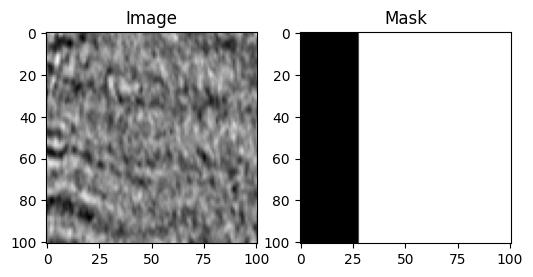

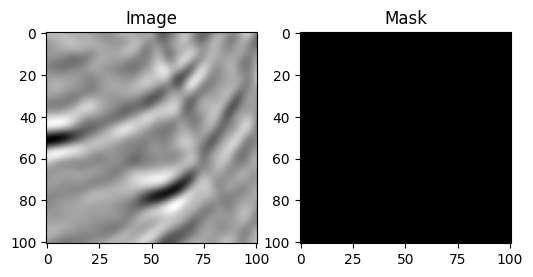

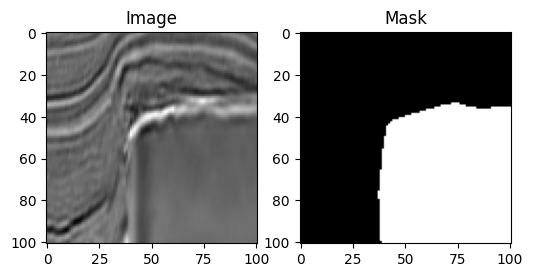

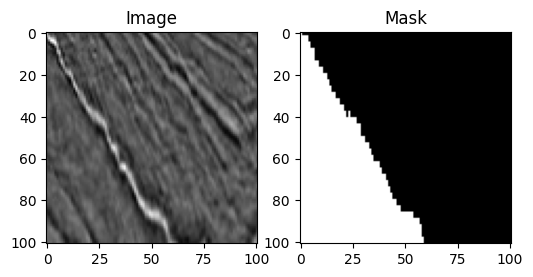

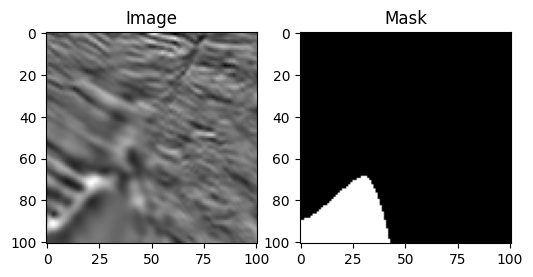

In [26]:
## iterate over each member of /train/images directory, plot image beside mask to see where salt is present in the train set
files = os.listdir(image_path)

for fname in files[:5]:  # first 5
    img = Image.open(os.path.join(image_path, fname))
    mask = Image.open(os.path.join(mask_path, fname))

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")

    plt.show()

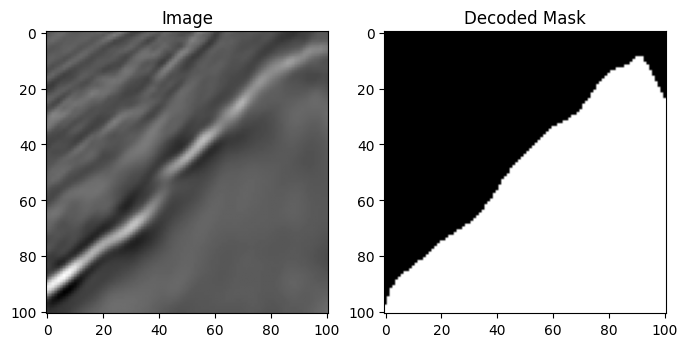

Salt presence frequency: 0.6095


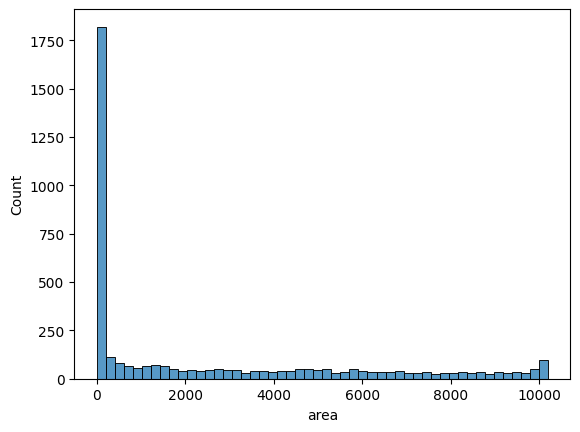

In [27]:
## decode the rle column in train.csv and visualize

def rle_decode(rle, shape=(101, 101)):
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    if pd.isna(rle):
        return mask.reshape(shape)

    s = list(map(int, rle.split()))
    starts, lengths = s[0::2], s[1::2]

    for start, length in zip(starts, lengths):
        start -= 1  ## convert to 0-index
        mask[start:start + length] = 1

    return mask.reshape(shape, order='F')  ## column-major

df = pd.read_csv(os.path.join(project_path, 'train.csv'))
row = df.iloc[0]

img = cv2.imread(f"{image_path}/{row['id']}.png", 0)
mask = rle_decode(row["rle_mask"])

## visualize decoded
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img, cmap="gray")

plt.subplot(1,2,2)
plt.title("Decoded Mask")
plt.imshow(mask, cmap="gray")

plt.show()

## measuring salta area from train.csv
def rle_area(rle):
    if pd.isna(rle):
        return 0
    s = list(map(int, rle.split()))
    lengths = s[1::2]
    return sum(lengths)

df["area"] = df["rle_mask"].apply(rle_area)

sns.histplot(df["area"], bins=50)

## measuring salt frequency from train.csv
df["has_salt"] = df["rle_mask"].notna()
print(f'Salt presence frequency: {df["has_salt"].mean()}')

In [28]:
## prepare data, normalize,

class SaltDataset(Dataset):
    def __init__(self, ids, image_dir, mask_dir=None):
        self.ids = ids
        self.image_dir = image_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]

        img_path = os.path.join(self.image_dir, id_)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)   # [1, H, W]

        if self.mask_dir is not None:
            mask_path = os.path.join(self.mask_dir, id_)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None:
                raise FileNotFoundError(f"Could not read mask: {mask_path}")

            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=0)   # [1, H, W]

            return torch.tensor(img), torch.tensor(mask)

        return torch.tensor(img)

In [29]:
## build dataset model can work with

## individual item id, same in masks as in images
ids = os.listdir(image_path)
ids = sorted(ids)
## test set is the evaluation set, so train set is split into train (80) and validation (20)
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=42)

batch_size = 16

train_dataset = SaltDataset(train_ids, image_path, mask_path)
val_dataset = SaltDataset(val_ids, image_path, mask_path)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [30]:
## prototype cnn model

## double convolution, extract features, detect patterns
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        ## encoder downsampling:
        ## resolution goes down 101>50>25
        ## channels go up 1>16>32
        ## zooms out to learn more abstract features
        self.enc1 = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        ## lowest resolution gives most global, abstract representation/ understanding of image
        self.bottleneck = DoubleConv(32, 64)
        ## decoder upsamples, increasing spatial resolution, reconstructing the image
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32, 16)
        ## 16 features map to 1 output channel, outputs = logits per pixel
        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        ## interpolation check, pooling and convolutions can change shape size. It is important size matches prior to concatenation.
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        ## skip connections combine high-level decoder and low-level encoder, without this, output would be blurry, edges would be lost.
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        return out

In [31]:
## counting loss
## dice and binary-cross-entropy-loss (BCE) are combined. This ensures [local accuracy + global structure] when calculating loss, as while Dice captures shape, BCE capture precise pixel probabilities.


def dice_loss(logits, targets, smooth=1e-6):
    ## Model outputs raw numbers (logits)
    ## Sigmoid converts to probabilities:
    ##    0 → no salt
    ##    1 → salt
    probs = torch.sigmoid(logits)
    ## flatten image
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    ## corresponds to prediction + groundtruth
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()

def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dloss = dice_loss(logits, targets)
    return bce + dloss

In [32]:
## metrics for evaluation

## Dice counts intersections twice. It answers "How much do the predicted salt pixels and true salt pixels overlap, relative to their total size?"

## IoU counts intersections once. It answers "How much of the combined area is shared?"

# So Dice is always higher than IoU for the same prediction. Dice is more forgiving for small objects.

def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    total = preds.sum(dim=1) + targets.sum(dim=1)
    union = total - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

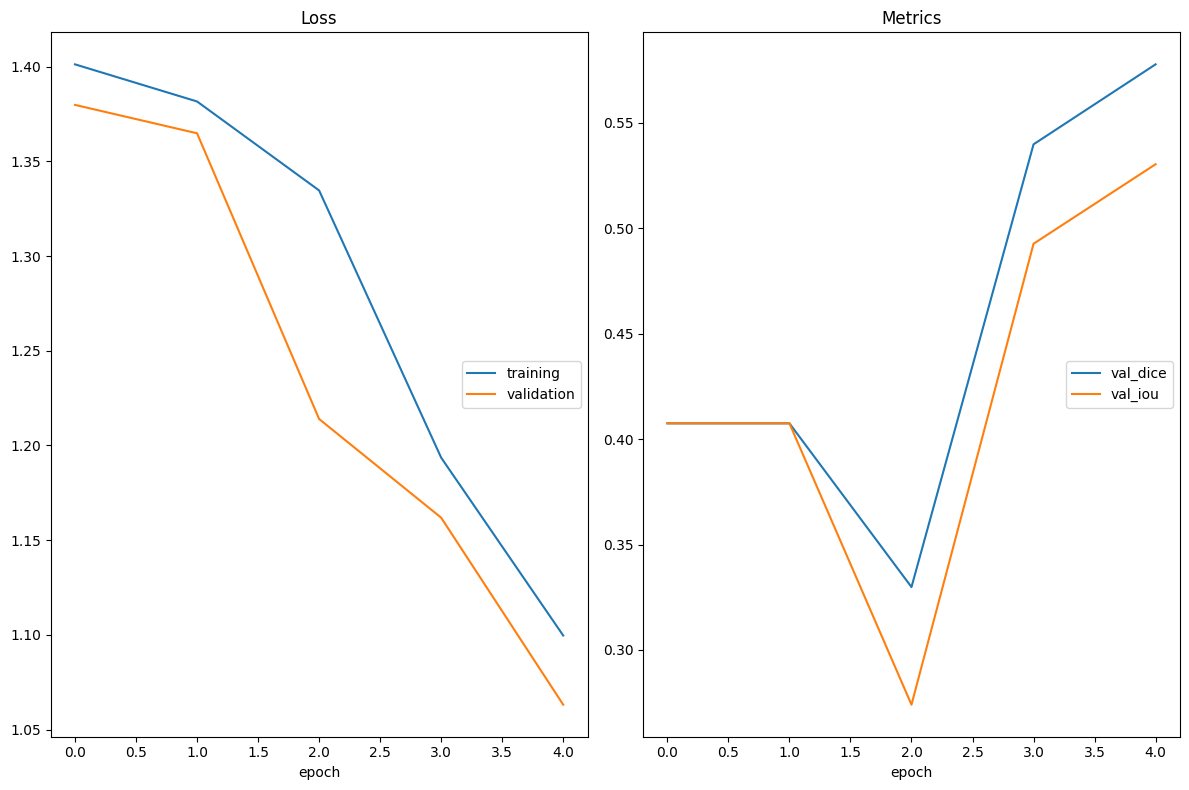

Loss
	training         	 (min:    1.100, max:    1.401, cur:    1.100)
	validation       	 (min:    1.063, max:    1.380, cur:    1.063)
Metrics
	val_dice         	 (min:    0.330, max:    0.578, cur:    0.578)
	val_iou          	 (min:    0.274, max:    0.530, cur:    0.530)
Epoch 6/10 | train_loss=1.0719 | val_loss=1.0537 | val_dice=0.5477 | val_iou=0.5011


In [ ]:
## training loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
console.print(Panel(Text(str(f'\n{device}\n'), justify="center"),title='Current Default Device:'))

model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

liveloss = PlotLosses(groups={'Loss': ['train_loss', 'val_loss'], 'Metrics': ['val_dice', 'val_iou']})

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            loss = bce_dice_loss(logits, masks)

            val_loss += loss.item()
            val_dice += dice_score(logits, masks)
            val_iou += iou_score(logits, masks)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)


    liveloss.update({
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_dice': val_dice,
        'val_iou': val_iou
    })
    # tell livelossplot to redraw the charts
    liveloss.send()

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_dice={val_dice:.4f} | "
        f"val_iou={val_iou:.4f}"
    )

In [ ]:
## visual evaluation

model.eval()
imgs, masks = next(iter(val_loader))
imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.8).float()

n = 10
for i in range(n):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes[0].imshow(imgs[i, 0].cpu().numpy(), cmap="gray")
    axes[0].set_title("Image")

    axes[1].imshow(masks[i, 0].cpu().numpy(), cmap="gray")
    axes[1].set_title("True Mask")

    axes[2].imshow(preds[i, 0].cpu().numpy(), cmap="gray")
    axes[2].set_title("Pred Mask")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()